# [Computational Social Science] Project 4: Unsupervised Learning

**Name:** Simon Cooper

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [1]:
import sys # Had to downgrade to Python 3.11. Confirming that it worked!
print(sys.version)

3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]


In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

In [3]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

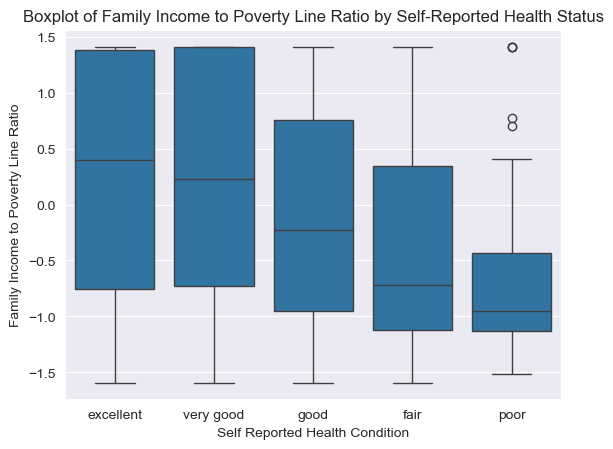

In [4]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

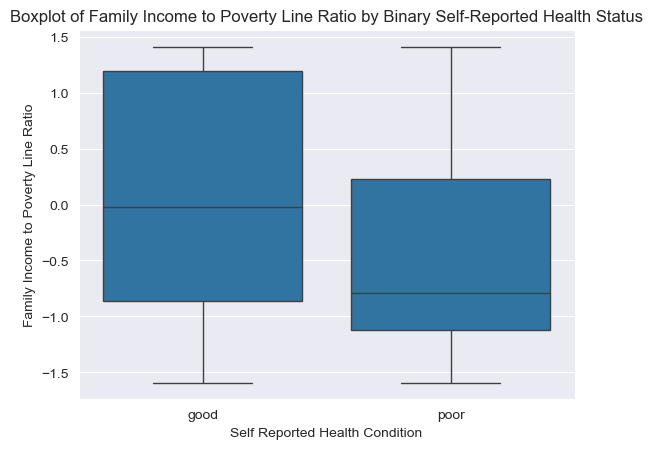

In [5]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

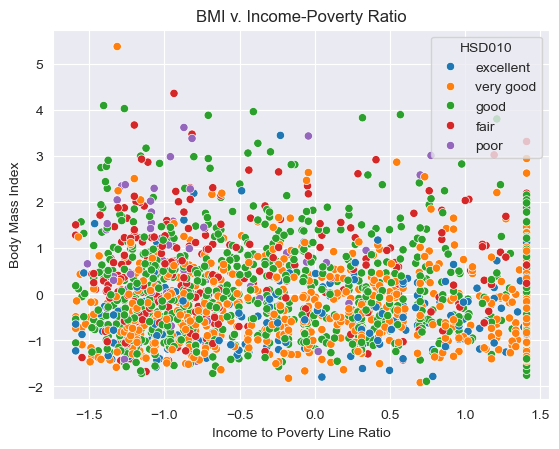

In [6]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [7]:
nhanes_scaled2= nhanes_scaled
nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

**Re-read James et al. section 12.2**
**Will mostly be editing code from Lab 4.1**

### Train PCA and Discuss Number of Components

To choose the number of components, I use a scree plot, which shows the amount of variance explained by each additional component. At the "elbow," or where the amount of variance explained drops off, we stop adding new components. Here, the drop off isn't super drastic, so this decision requires a little judgment. Through trial and error, I identified the principal components that explain ~80 percent of the variation, which are the first 85. I could've picked a larger number of components, but I'm worried about computational power.

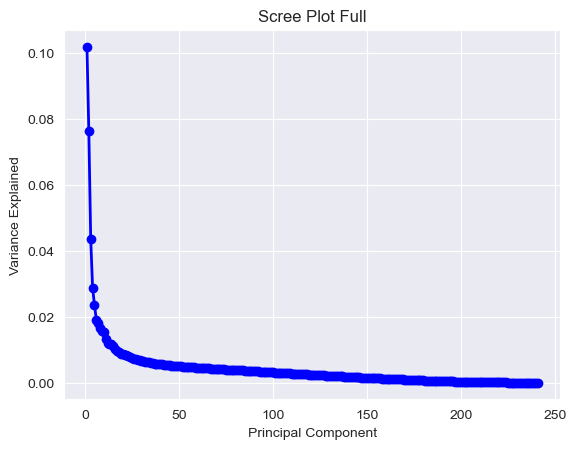

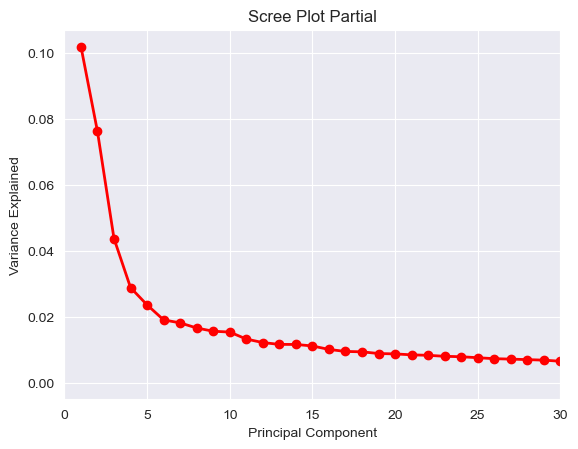

0.79470453161864


In [8]:

# Fitting PCA.
pca_all = PCA()
principalComponents = pca_all.fit_transform(nhanes_scaled)

# Creating scree plot from PCA fit.
PC_values = np.arange(pca_all.n_components_) + 1
plt.plot(PC_values, pca_all.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot Full')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()
# This first version is too hard to read. Creating a version where x-axis only goes from 0 to 30
# so I can see the "elbow."
PC_values = np.arange(pca_all.n_components_) + 1
plt.plot(PC_values, pca_all.explained_variance_ratio_, 'o-', linewidth=2, color='red')
plt.title('Scree Plot Partial')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xlim(0, 30)
plt.show()

# Re-fitting PCA with 85 components.
pca_eightyfive = PCA(n_components=85)
principalComponents = pca_eightyfive.fit_transform(nhanes_scaled)

total_variance_explained = pca_eightyfive.explained_variance_ratio_.sum()
print(total_variance_explained)


### Barplot of Components

<Figure size 640x480 with 0 Axes>

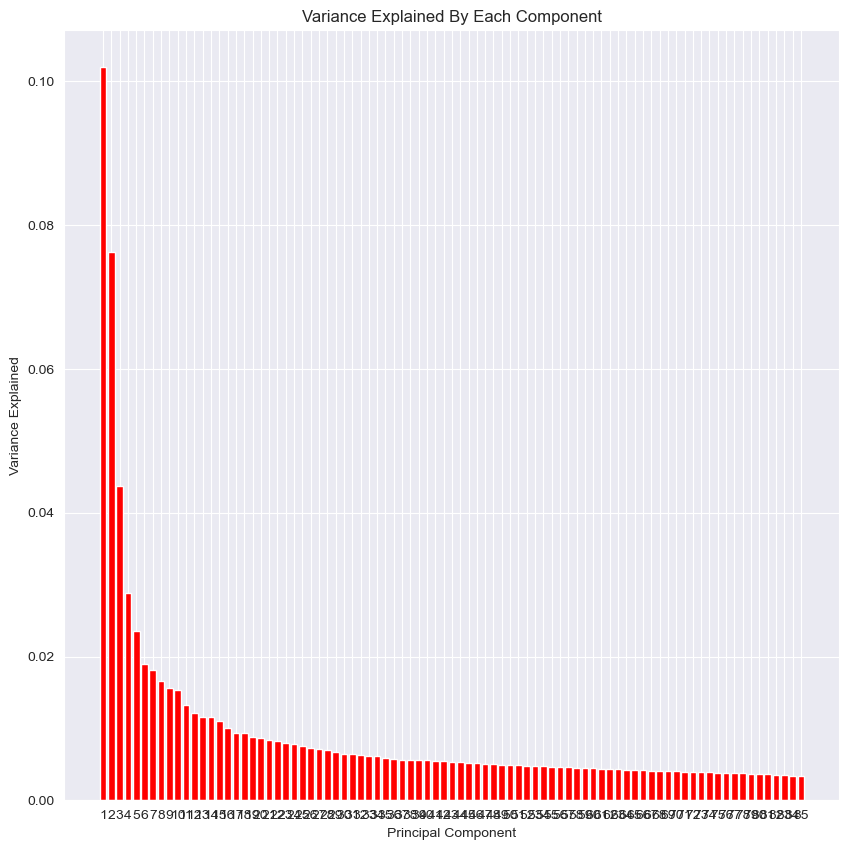

In [9]:

# Making barplot.
plt.figure()
plt.figure(figsize=(10,10))
PC_values = np.arange(pca_eightyfive.n_components_) + 1
plt.bar(PC_values, pca_eightyfive.explained_variance_ratio_, color='red')
plt.title('Variance Explained By Each Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(PC_values)
plt.show()


### How many components will you use to fit a supervised learning model?

For my supervised learning model, I plan to use 85 components, guided by the scree plot and the bar plot. The amount of variance explained by the first 85 features is approximately 80 percent, suggesting to me that this number of components will help me strike a good balance between model performance and computational efficiency.

### 2D Scatterplot of the first two components

Looking at the PCA scatterplot, there appears to be considerable overlap among the self-reported health categories when only two components are used. This overlap makes sense given that the first two principal components explained <20 percent of the variation. 

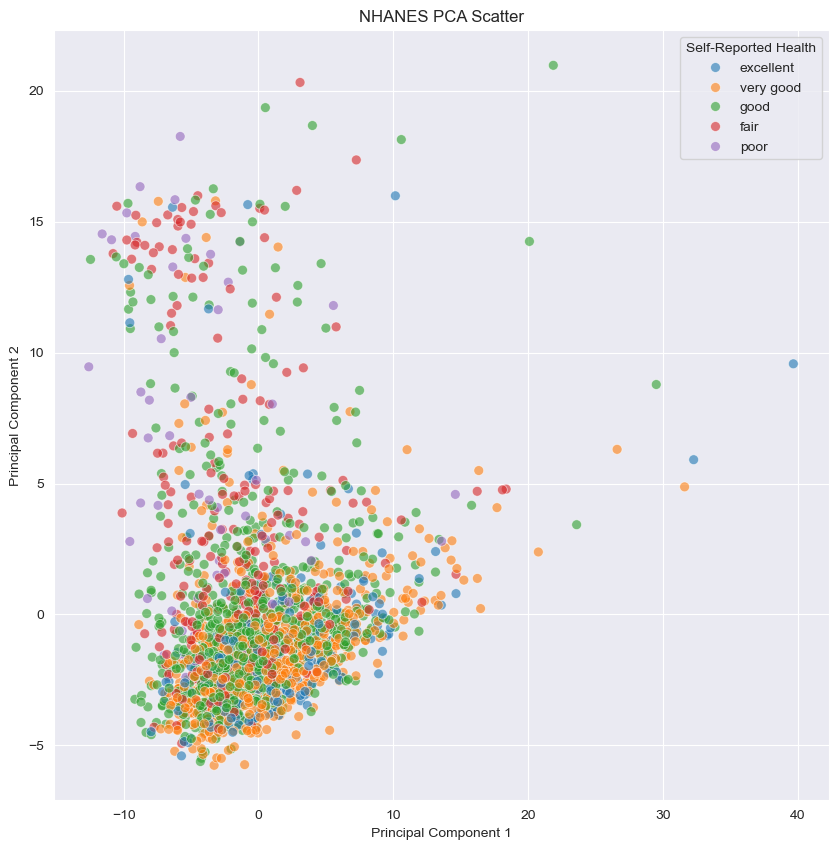

In [17]:

# Re-fitting PCA with 2 components.
pca_two = PCA(n_components=2)
pca_df = pd.DataFrame(
    data=pca_two.fit_transform(nhanes_scaled),
    columns=['principal component 1', 'principal component 2'])

# Creating plot df.
plot_df = pca_df.copy()
plot_df['Category5'] = nhanes_scaled2['HSD010'].values
plot_df['Category2'] = nhanes_scaled2['HSD010'].values

# Making scatterplot.
plt.figure(figsize=(10,10))
sns.scatterplot(data=plot_df,
                x='principal component 1',
                y='principal component 2',
                hue='Category5',
                palette='tab10',
                s=50,
                alpha=0.6)

plt.legend(title='Self-Reported Health')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('NHANES PCA Scatter')
plt.show()


## K-Means

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

**Re-read James et al. 12.4.1.**
**Editing code from Lab 4.1**

### Choose a Clustering Algorithm

For my clustering algorithm, I chose k-means clustering. Each observation is initially randomly assigned a number between 1 and k. The algorithm calculates the centroid for each randomly-assigned cluster, then, re-assigns each observation to the nearest cluster centroid (even if this centroid is not for that observation's current cluster). It repeats this process until the cluster assignments are unchanging.

### Cluster nhanes

Choosing the right number of clusters requires some judgment/involves some arbitrariness. Here, I choose k = 5, hoping that the clusters conform to each of the 5 possible responses to the general health question (HSD010; Excellent, very good, fair, and poor). 

In [25]:
# Setting random seed.
np.random.seed(10)

# Creating the model.
kmeans = KMeans(n_clusters=5,
                n_init=10,
                max_iter=300
               ).fit(nhanes_scaled)

# Code for printing coordinates and labels. Commenting out since it's long.
# for point, label in zip(nhanes_scaled, kmeans.labels_):
# print("Coordinates:", point, "Label:", label)


### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

Cluster 1 (orange) seems to be concentrated among people with higher income to poverty line ratios (richer people). Cluster 4 (purple) seems to be concentrated among people with lower BMIs. Cluster 0 (blue) appears to be roughly concentrated among people with higher BMIs and lower incomes. To me, these results suggest that the clusters are somewhat informative. However, the high degree of overlap makes a straightforward interpretation difficult.

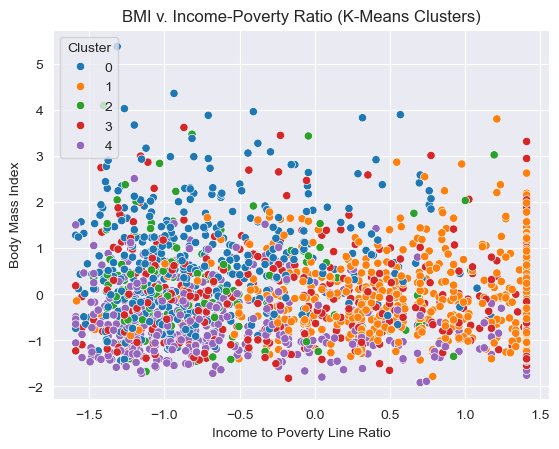

In [26]:
# Adding cluster labels.
nhanes_scaled['cluster'] = kmeans.labels_

# Re-creating the plot with clusters.
ax = sns.scatterplot(x="INDFMPIR", y="BMXBMI", hue="cluster", palette="tab10", data=nhanes_scaled)
ax.set(xlabel="Income to Poverty Line Ratio",
       ylabel="Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio (K-Means Clusters)")
plt.legend(title='Cluster')
plt.show()


### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

Here, the separation among the clusters is much clearer. This improved separation makes sense given that the k-means algorithm is now drawing on the 85 principal components that explain 80 percent of the variance. Our visualization shows us where these clusters fall on the first 2 of these 85 principal components.

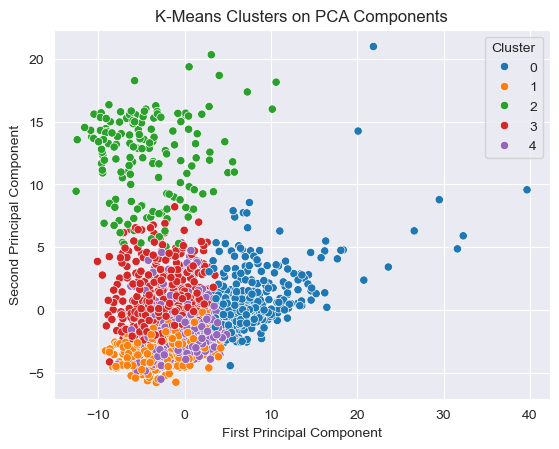

In [27]:

# Converting PCA-transformed data to dataframe.
pca_df = pd.DataFrame(data=principalComponents, 
                      columns=[f'PC{i+1}' for i in range(85)])

# Fitting K-Means on PCA components.
np.random.seed(10)
kmeans_pca = KMeans(n_clusters=5,
                    n_init=10,
                    max_iter=300).fit(pca_df)

# Adding cluster labels to 2D PCA dataframe.
pca_2d_df = pd.DataFrame(data=principalComponents[:, :2], 
                         columns=['PC1', 'PC2'])
pca_2d_df['cluster'] = kmeans_pca.labels_

# Making scatterplot.
ax = sns.scatterplot(x='PC1', y='PC2', hue='cluster', palette='tab10', data=pca_2d_df)
ax.set_title('K-Means Clusters on PCA Components')
ax.set(xlabel='First Principal Component',
       ylabel='Second Principal Component')
plt.legend(title='Cluster')
plt.show()


## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

**Re-read James et al. 10.1, 10.2, 10.6, 10.7. May need to reference 10.3-10.5.**. 
**Editing code from Lab 3.4 + updating this template.**

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features

In [15]:
# partition data
# -----------
y = ... # either hsd010 or hsd010_binary, may need to convert to numeric if it isn't already 
X = ... # drop out any columns that aren't features

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

TypeError: Input should have at least 1 dimension i.e. satisfy `len(x.shape) > 0`, got scalar `array(Ellipsis, dtype=object)` instead.

In [ ]:
# load libraries
# -----------
import keras
from keras.utils import to_categorical

num_classes = ...
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(..., ...)
y_test = keras.utils.to_categorical(..., ...)
num_classes = y_test.shape[1]

In [ ]:
# create neural network model
# -----------
model = Sequential()

model.add(Dense(..., input_dim= ..., kernel_initializer= ..., activation= ...))

model.add(Dense(..., kernel_initializer= ..., activation= ...))

## Add any additional layers you wish here

model.compile(loss= ..., optimizer= ..., metrics=[...])

model.fit(..., ..., validation_data=(..., ...), epochs=..., batch_size=..., verbose=...)

### Neural Network on Principal Components

In [ ]:
## Your Answer Here

### Neural Network on Principal Components + Cluster Membership

In [ ]:
## Your Answer Here

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

Principal components analysis (PCA) is a form of unsupervised learning used for dimensionality reduction. PCA helps us identify the most interesting components. There are two ways of understanding what makes components interesting: (1) interesting components are those that contain the most variation and (2) interesting components are those that are nearest to the observations (on the premise that these will summarize the data best).  

Clustering is also a form of unsupervised learning; however, where PCA identifies components that explain variance, clustering identifes preexisting (although often as-yet-unobserved) groups within the data. In each cluster, variation is *minimized*. There are numerous types of clustering, but here we use k-means clustering, which identifies a pre-specified number of clusters.

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

Yes, I saw some pretty impressive advantages from combining PCA and clustering. When I re-trained the k-means algorithm for clustering on the PCA-transformed data, I got much better separation among my 5 clusters than I got using clustering alone. I think this is because the PCA performed helpful dimensionality reduction, reducing noise while preserving signal.

However, xx.

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

When working with "big" data, unsupervised techniques can help with downstream learning tasks in at least three ways. First, unsupervised learning techniques (such as clustering) can help identify groups that would be invisible to the analyst (either because they are not theorized in the literature and/or because the original data is simply too large). Second, and relatedly, they yield helpful, interpretable data visualizations. Third, these techniques can help with dimensionality reduction, allowing analysts to preserve predictive performance without expending too much computational power.